In [1]:
import sys
sys.path.append('../')
from qufold import MiyazawaJerniganInteraction, Peptide, ProteinFoldingProblem, PenaltyParameters
from qiskit.circuit.library import RealAmplitudes
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.minimum_eigensolvers import SamplingVQE
from qiskit.primitives import Sampler
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def build_pf(main_seq: str, energy_matrix_file: str = "mj_matrix"):
    """Builds the protein folding problem for the given sequence."""
    # Define the interaction
    side_chains = [""] * len(main_seq)

    mj_interaction = MiyazawaJerniganInteraction(energy_matrix_file)

    penalty_back = 10
    penalty_chiral = 10
    penalty_1 = 10

    penalty_terms = PenaltyParameters(penalty_chiral, penalty_back, penalty_1)

    peptide = Peptide(main_seq, side_chains)

    protein_folding_problem = ProteinFoldingProblem(peptide, mj_interaction, penalty_terms)

    return protein_folding_problem

In [3]:
main_chain = "GSNQNNF"
# main_chain_1 = "LHPGAGK"
# main_chain_2 = "APRLRFY"
# main_chain = "YYDPETGTWY"
# pf1 = build_pf(main_chain_1, "mj_matrix")
# pf2 = build_pf(main_chain_1, "contactenergies_2003")

# Get the qubit operators
# qubit_op_1 = pf1.qubit_op()
# qubit_op_2 = pf2.qubit_op()
# qubit_op_1 == qubit_op_2
# qubit_op_2 = pf2.qubit_op()

pf = build_pf(main_chain, "mj_matrix")
qubit_op = pf.qubit_op()

# # Write the qubit operator to a txt file
# f = open("hamiltonian_7AA_GSNQNNF.txt", "w")
# for op, coeff in qubit_op.to_list():
#     coeff_real = np.real(coeff)
#     if np.sign(coeff_real) > 0:
#         f.write(f"+ {coeff_real} * {op}\n")
#     else:
#         f.write(f"- {-coeff_real} * {op}\n")
# f.close()

In [7]:
# Top 3 degenerate solutions for the 7AA GSNQNNF sequence
opt_bitstring = "101100011"
# opt_bitstring = "101000010"
# opt_bitstring = "101000110"
res = pf.interpret_bitstring(opt_bitstring)
res.save_xyz_file("6VHB_tetrahedral")

In [ ]:
main_chain_3 = "DAYAQWLKDGGPSSGRPPPS" # 20-AA Trp-Cage
pf3 = build_pf(main_chain_3)
qubit_op_3 = pf3.qubit_op()
# print(len(qubit_op_3))
print(qubit_op_3)

In [ ]:
main_chain_4 = "YYDPETGTWY" # 10-AA chignolin
pf4 = build_pf(main_chain_4)
qubit_op_4 = pf4.qubit_op()
print(qubit_op_4)

In [ ]:
main_chain_5 = "DRVYIHPFHL" # 10-AA angiotensin
pf5 = build_pf(main_chain_5)
qubit_op_5 = pf5.qubit_op()
print(qubit_op_5)

In [ ]:
main_chain_6 = "VLAMWKVGFFKRNRP" # 15-AA integrin
pf6 = build_pf(main_chain_6)
qubit_op_6 = pf6.qubit_op()
print(qubit_op_6)

In [13]:
def run_vqe(qubit_op):
    # set classical optimizer
    optimizer = COBYLA(maxiter=100)

    # set variational ansatz
    ansatz = RealAmplitudes(reps=1)

    counts = []
    values = []

    def store_intermediate_result(eval_count, parameters, mean, std):
        counts.append(eval_count)
        values.append(mean)

    # initialize VQE using CVaR with alpha = 0.1
    vqe = SamplingVQE(
        Sampler(),
        ansatz=ansatz,
        optimizer=optimizer,
        aggregation=0.1,
        callback=store_intermediate_result,
    )

    raw_result = vqe.compute_minimum_eigenvalue(qubit_op)

    return raw_result, counts, values

In [14]:
raw_result_1, counts_1, values_1 = run_vqe(qubit_op_1)

/Users/ruihaoli/opt/miniconda3/envs/qc_pf/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/ruihaoli/opt/miniconda3/envs/qc_pf/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


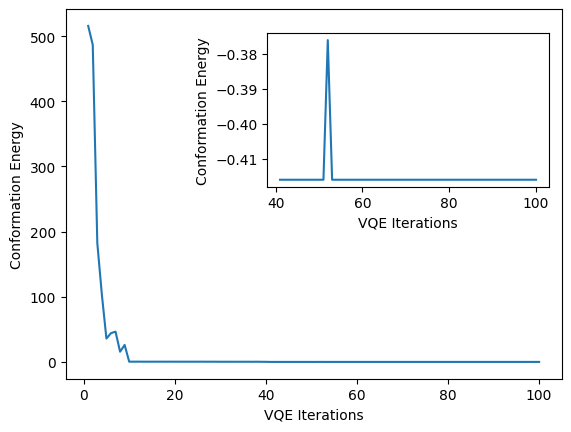

In [15]:
fig = plt.figure()

plt.plot(counts_1, values_1)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts_1[40:], values_1[40:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

In [14]:
raw_result_2, counts_2, values_2 = run_vqe(qubit_op_2)

/Users/lir9/miniconda3/envs/pf_qiskit_1/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lir9/miniconda3/envs/pf_qiskit_1/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


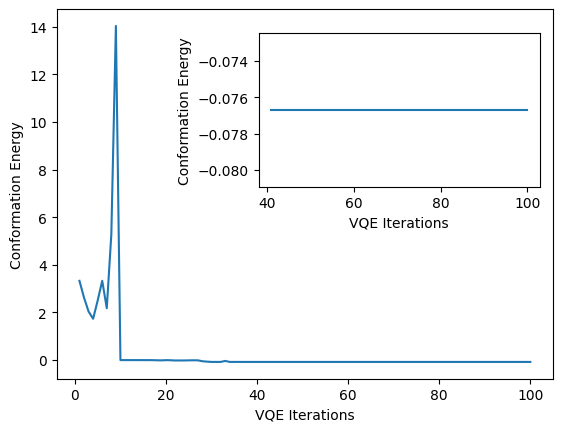

In [15]:
fig = plt.figure()

plt.plot(counts_2, values_2)
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")

fig.add_axes([0.44, 0.51, 0.44, 0.32])

plt.plot(counts_2[40:], values_2[40:])
plt.ylabel("Conformation Energy")
plt.xlabel("VQE Iterations")
plt.show()

The bitstring representing the shape of the protein during optimization is:  010100101
The expanded expression is: 0______1_____________________________________________________________________________________________________________________________010010_1____
The folded protein's main sequence of turns is: [1, 0, 3, 1, 0, 2]
and the side turn sequences are: [None, None, None, None, None, None, None]


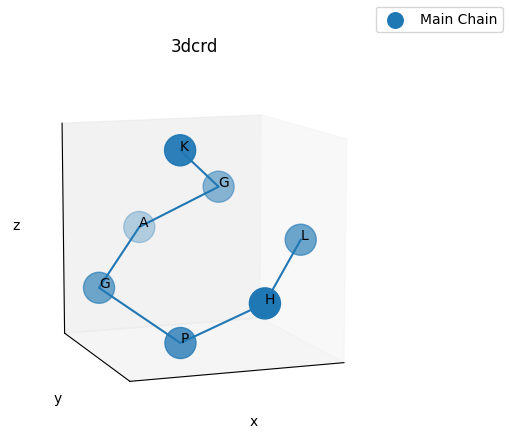

In [16]:
result = pf1.interpret(raw_result=raw_result_1)
print(
    "The bitstring representing the shape of the protein during optimization is: ",
    result.turn_sequence,
)
print("The expanded expression is:", result.get_result_binary_vector())

##

print(f"The folded protein's main sequence of turns is: {result.protein_shape_decoder.main_turns}")
print(f"and the side turn sequences are: {result.protein_shape_decoder.side_turns}")

fig = result.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)

In [19]:
from qufold.execution_utils.measurements import _evaluate_sparsepauli

print(_evaluate_sparsepauli("010100101", qubit_op_1))
print(_evaluate_sparsepauli("000100101", qubit_op_1))

-0.4159999999998263
-1.1368683772161603e-13


The bitstring representing the shape of the protein during optimization is:  010100101
The expanded expression is: 0______1_____________________________________________________________________________________________________________________________010010_1____
The folded protein's main sequence of turns is: [1, 0, 3, 1, 0, 2]
and the side turn sequences are: [None, None, None, None, None, None, None]


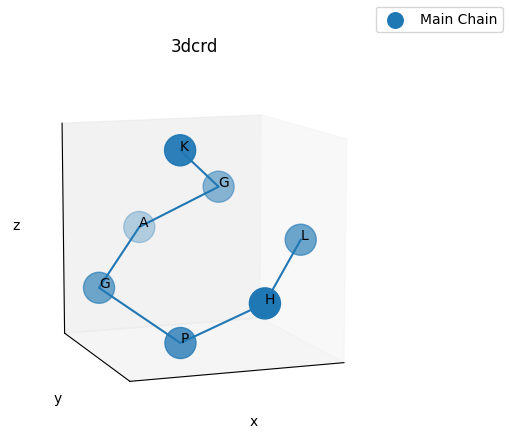

In [32]:
result = pf2.interpret(raw_result=raw_result_2)
print(
    "The bitstring representing the shape of the protein during optimization is: ",
    result.turn_sequence,
)
print("The expanded expression is:", result.get_result_binary_vector())

##

print(f"The folded protein's main sequence of turns is: {result.protein_shape_decoder.main_turns}")
print(f"and the side turn sequences are: {result.protein_shape_decoder.side_turns}")

fig = result.get_figure(title="3dcrd", ticks=False, grid=True)
fig.get_axes()[0].view_init(10, 70)

In [20]:
# chignolin optimal solutions (2 degenerate)
opt_bitstring_1 = "0100001000011011011011"
opt_bitstring_2 = "0100001000011001011001"
opt_bitstring_3 = "0100001000001001001001"

result_1 = pf.interpret_bitstring(opt_bitstring_1)
result_2 = pf.interpret_bitstring(opt_bitstring_2)
result_3 = pf.interpret_bitstring(opt_bitstring_3)

In [21]:
# multiply numerical values by 3.8
xyz_coords_1 = result_1.protein_shape_file_gen.get_xyz_data()
for i in range(len(xyz_coords_1)):
    for j in range(1, len(xyz_coords_1[i])):
        xyz_coords_1[i][j] = float(xyz_coords_1[i][j]) * 3.8

print(xyz_coords_1)

[['Y' '0.0' '0.0' '0.0']
 ['Y' '2.193931022920578' '2.193931022920578' '-2.193931022920578']
 ['D' '4.387862045841156' '0.0' '-4.387862045841156']
 ['P' '6.581793068761734' '-2.193931022920578' '-2.193931022920578']
 ['E' '8.775724091682312' '0.0' '0.0']
 ['T' '10.96965511460289' '-2.193931022920578' '2.193931022920578']
 ['G' '8.775724091682312' '-4.387862045841156' '4.387862045841156']
 ['T' '6.581793068761734' '-6.581793068761734' '2.193931022920578']
 ['W' '4.387862045841157' '-4.387862045841157' '0.0']
 ['Y' '2.193931022920579' '-2.193931022920579' '2.193931022920578']]


In [22]:
xyz_coords_2 = result_2.protein_shape_file_gen.get_xyz_data()
for i in range(len(xyz_coords_2)):
    for j in range(1, len(xyz_coords_2[i])):
        xyz_coords_2[i][j] = float(xyz_coords_2[i][j]) * 3.8

print(xyz_coords_2)

[['Y' '0.0' '0.0' '0.0']
 ['Y' '2.193931022920578' '2.193931022920578' '-2.193931022920578']
 ['D' '4.387862045841156' '0.0' '-4.387862045841156']
 ['P' '6.581793068761734' '-2.193931022920578' '-2.193931022920578']
 ['E' '8.775724091682312' '-4.387862045841156' '-4.387862045841156']
 ['T' '10.96965511460289' '-6.581793068761734' '-2.193931022920578']
 ['G' '8.775724091682312' '-8.775724091682312' '0.0']
 ['T' '6.581793068761734' '-6.581793068761734' '2.193931022920578']
 ['W' '4.387862045841157' '-4.387862045841157' '0.0']
 ['Y' '2.193931022920579' '-2.193931022920579' '2.193931022920578']]


In [23]:
xyz_coords_3 = result_3.protein_shape_file_gen.get_xyz_data()
for i in range(len(xyz_coords_3)):
    for j in range(1, len(xyz_coords_3[i])):
        xyz_coords_3[i][j] = float(xyz_coords_3[i][j]) * 3.8

print(xyz_coords_3)

[['Y' '0.0' '0.0' '0.0']
 ['Y' '2.193931022920578' '2.193931022920578' '-2.193931022920578']
 ['D' '4.387862045841156' '0.0' '-4.387862045841156']
 ['P' '6.581793068761734' '-2.193931022920578' '-2.193931022920578']
 ['E' '8.775724091682312' '-4.387862045841156' '-4.387862045841156']
 ['T' '6.581793068761734' '-6.581793068761734' '-6.581793068761734']
 ['G' '4.387862045841157' '-8.775724091682312' '-4.387862045841157']
 ['T' '2.193931022920579' '-6.581793068761734' '-2.193931022920579']
 ['W' '4.387862045841157' '-4.387862045841157' '-8.437694987151189e-16']
 ['Y' '2.193931022920579' '-2.193931022920579' '2.193931022920577']]
